# Impact of $A$ on a simple dipole map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when no other effect but the monopole is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Reading data

In [4]:
DIR = "Fit_Dipole/Dipole_Monopole/Dipole_Monopole_"
sufix = "Param_study"
file = DIR + sufix +".fits"

data2 = fitsio.FITS(file)
data2


  file: Fit_Dipole/Dipole_Monopole/Dipole_Monopole_Param_study.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [5]:
dfMinuit_filtered = Table(data2['A_STUDY'].read())
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true
str3,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64
NaN,1000000.0005751855,1000000.0,4.510548978461884,False,0.0,inf,0.0009999988497109112,1.0,7.812457630320844e-06,False,0.0,1.0,167.99998098764206,100.0,0.45098207280629765,False,0.0,360.0,-7.000061763618745,0.0,0.4476265922571283,False,-90.0,90.0,True,1000000,0.001,168,-7
NaN,1000000.0044884902,1000000.0,4.510548978461884,False,0.0,inf,0.0010985473022511719,1.0,7.812443942201196e-06,False,0.0,1.0,167.99888909192308,100.0,0.4105277840746595,False,0.0,360.0,-7.002027764630587,0.0,0.407472922685308,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7
NaN,1000000.0001346475,1000000.0,4.510548977530561,False,0.0,inf,0.0012067918014424964,1.0,7.812455690244056e-06,False,0.0,1.0,168.00009388951918,100.0,0.3737030290295422,False,0.0,360.0,-7.000012663123524,0.0,0.3709229136264698,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7
NaN,999999.9999719296,1000000.0,4.510548977879807,False,0.0,inf,0.001325715286034104,1.0,7.812447867615985e-06,False,0.0,1.0,168.0000354757379,100.0,0.34018060135915107,False,0.0,360.0,-7.00001443235529,0.0,0.33764999070462265,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7
NaN,1000000.000082925,1000000.0,4.510548978461884,False,0.0,inf,0.0014563505134825552,1.0,7.812450060435587e-06,False,0.0,1.0,168.0002730607825,100.0,0.30966601612990985,False,0.0,360.0,-6.999973105392667,0.0,0.30736251852169616,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7
NaN,1000000.0006636636,1000000.0,4.510548977763392,False,0.0,inf,0.0015998592074718382,1.0,7.812451165697845e-06,False,0.0,1.0,168.00008665551243,100.0,0.281888541809721,False,0.0,360.0,-6.999828636020964,0.0,0.27979175734097605,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7
NaN,999999.999097587,1000000.0,4.510548978345469,False,0.0,inf,0.0017575118581956513,1.0,7.81244916873763e-06,False,0.0,1.0,168.00006323086242,100.0,0.25660262168469217,False,0.0,360.0,-6.999976095089156,0.0,0.25469395035223164,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7
NaN,1000000.0006775175,1000000.0,4.510548977763392,False,0.0,inf,0.0019307352685904327,1.0,7.812411131180802e-06,False,0.0,1.0,168.0001350701541,100.0,0.23358236763799312,False,0.0,360.0,-6.998621631237775,0.0,0.23184516926191723,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7
NaN,999999.997372566,1000000.0,4.510548978345469,False,0.0,inf,0.002120950419226652,1.0,7.812447683494279e-06,False,0.0,1.0,168.00000705542539,100.0,0.21263207369844395,False,0.0,360.0,-7.000312733365899,0.0,0.2110504848470005,False,-90.0,90.0,True,1000000,0.0021209508879201904,168,-7


#### Plotting graphs

Saving Dip_A_study_val in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_val.pdf


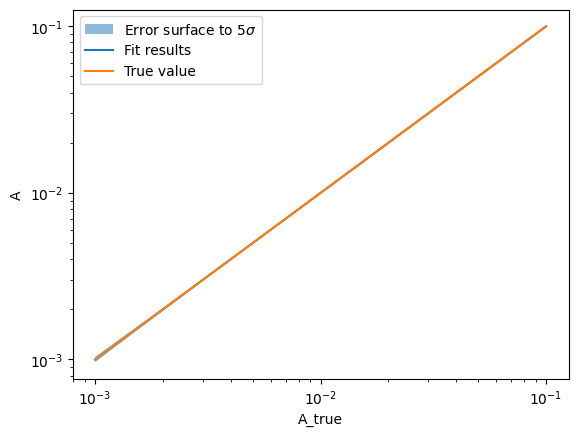

In [7]:
compareFit_val(dfMinuit_filtered, "A", "A", yscale='log', nsigma=5)
output_path = "Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/"
sufix = "Dip_A_study_val"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_err in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_err.pdf


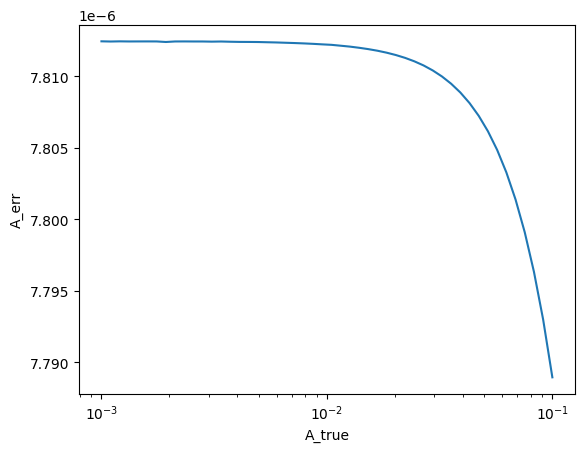

In [8]:
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_err"], label="Fit error")
plt.xlabel('A_true')
plt.ylabel('A_err')
plt.xscale('log');

sufix = "Dip_A_study_err"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_diff in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_diff.pdf


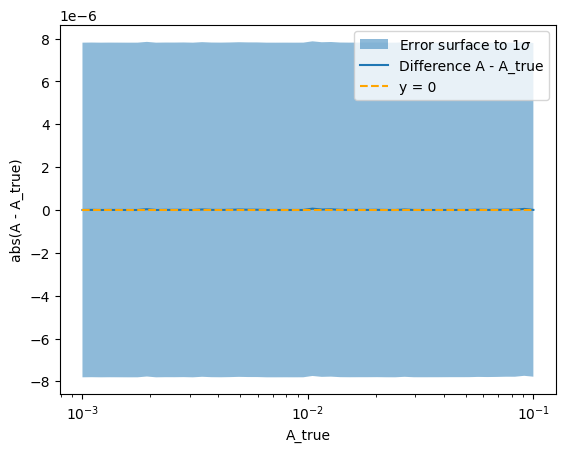

In [9]:
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=1)
sufix = "Dip_A_study_diff"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_valRA in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_valRA.pdf


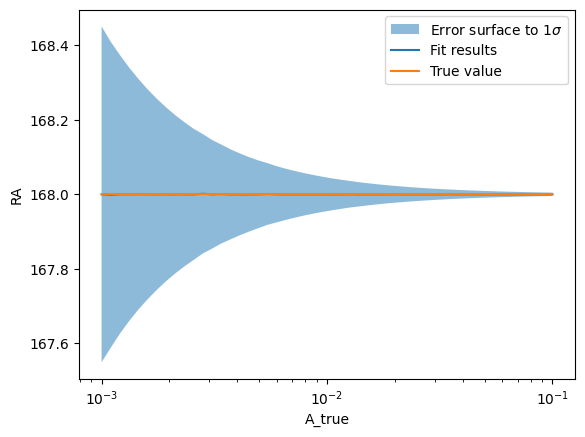

In [10]:
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=1)

sufix = "Dip_A_study_valRA"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_diffRA in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_diffRA.pdf


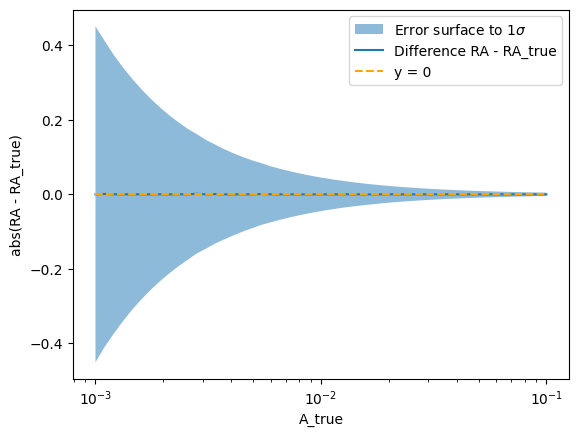

In [11]:
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1)

sufix = "Dip_A_study_diffRA"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_valDEC in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_valDEC.pdf


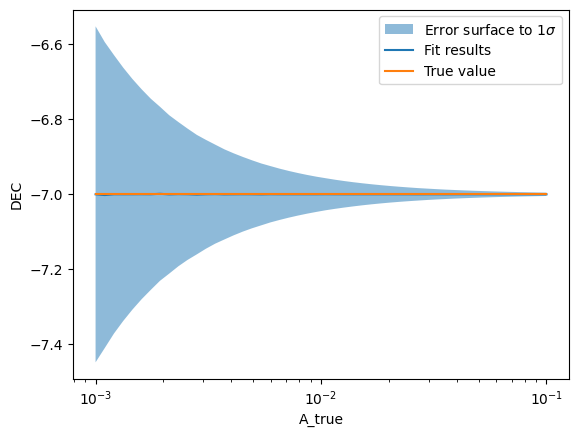

In [12]:
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=1)

sufix = "Dip_A_study_valDEC"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_diffDEC in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_diffDEC.pdf


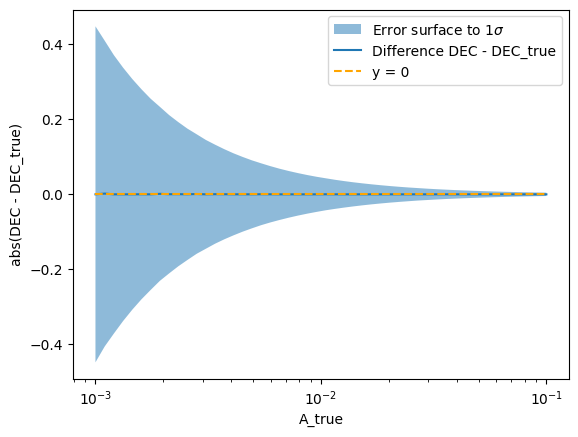

In [13]:
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1)

sufix = "Dip_A_study_diffDEC"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_diffARaDec in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_diffARaDec.pdf


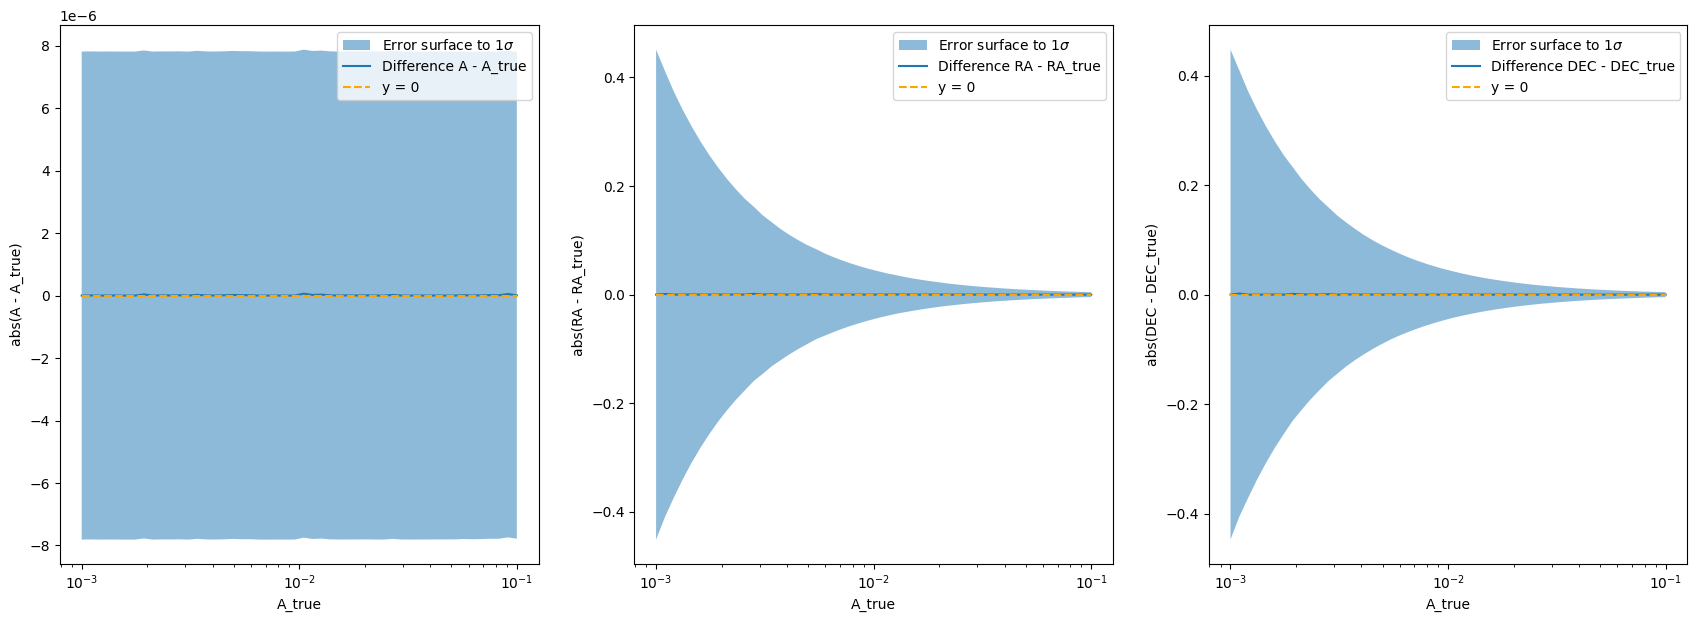

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]))

sufix = "Dip_A_study_diffARaDec"
get_savefig(plt, output_path, sufix)

Saving Dip_A_study_ratioARaDec in Simul_Figures/Simul_Dip/Simul_Dip_ParamStudy/Dip_A_study_ratioARaDec.pdf


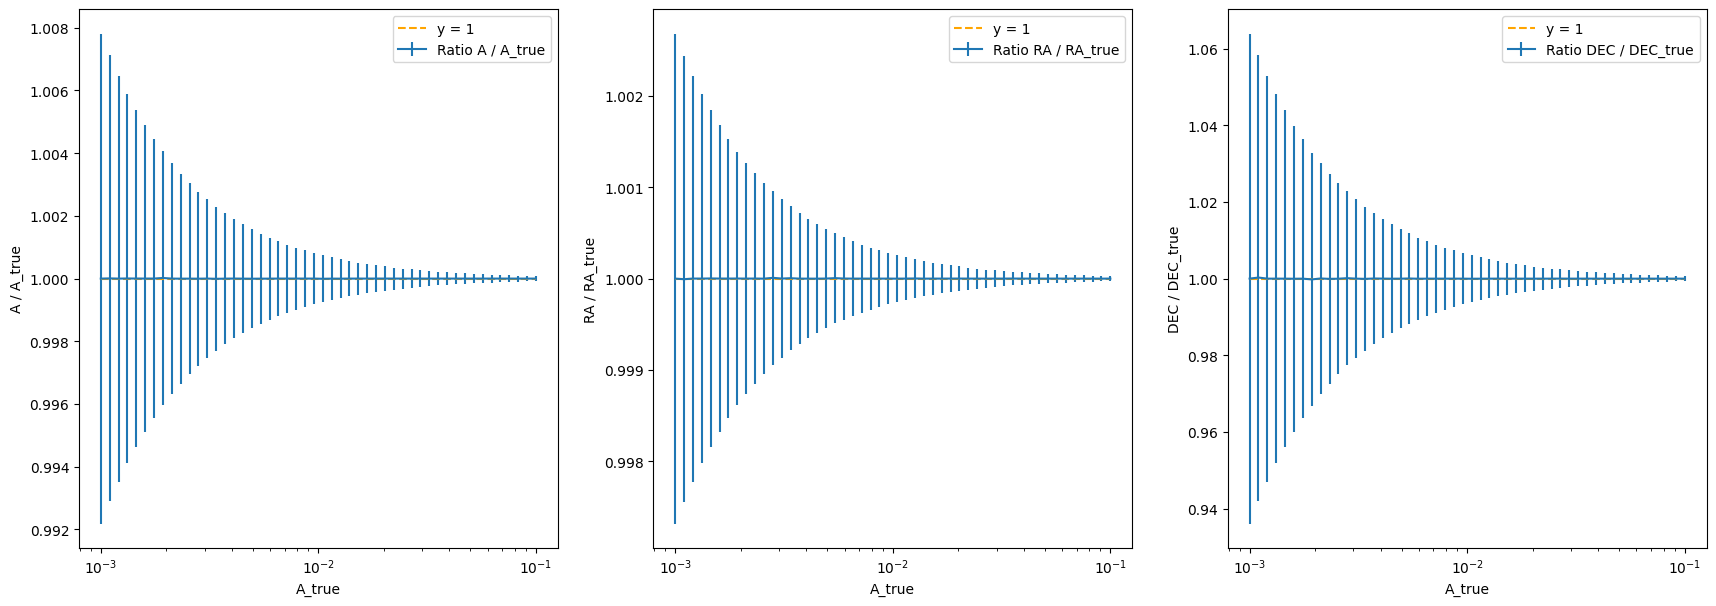

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Dip_A_study_ratioARaDec"
get_savefig(plt, output_path, sufix)